**Task 4 : Disease Prediction from Medical Data**

In [1]:
# Load Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

**Breast-Cancer Dataset**

In [2]:
# Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name='target'
)

print("Dataset shape:", X.shape)

display(X.head())

Dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Understand Target

print(data.target_names)

['malignant' 'benign']


In [4]:
# Dataset Information

print(X.info())

print("\nMissing values:")

print(X.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

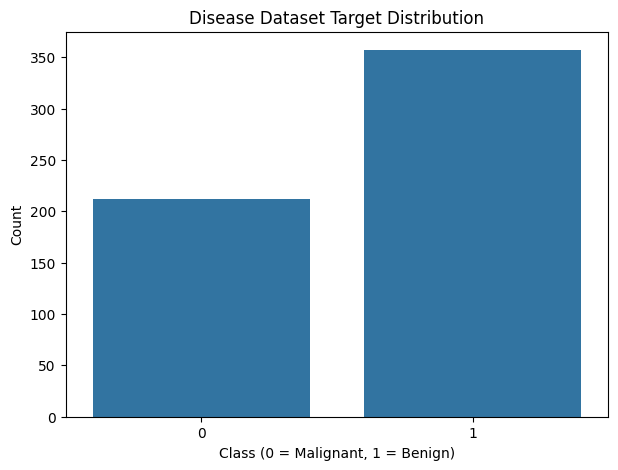

In [5]:
# Target Distrubution

plt.figure(figsize=(7,5))

sns.countplot(
    x=y
)

plt.title("Disease Dataset Target Distribution")

plt.xlabel(
    "Class (0 = Malignant, 1 = Benign)"
)

plt.ylabel("Count")

plt.show()

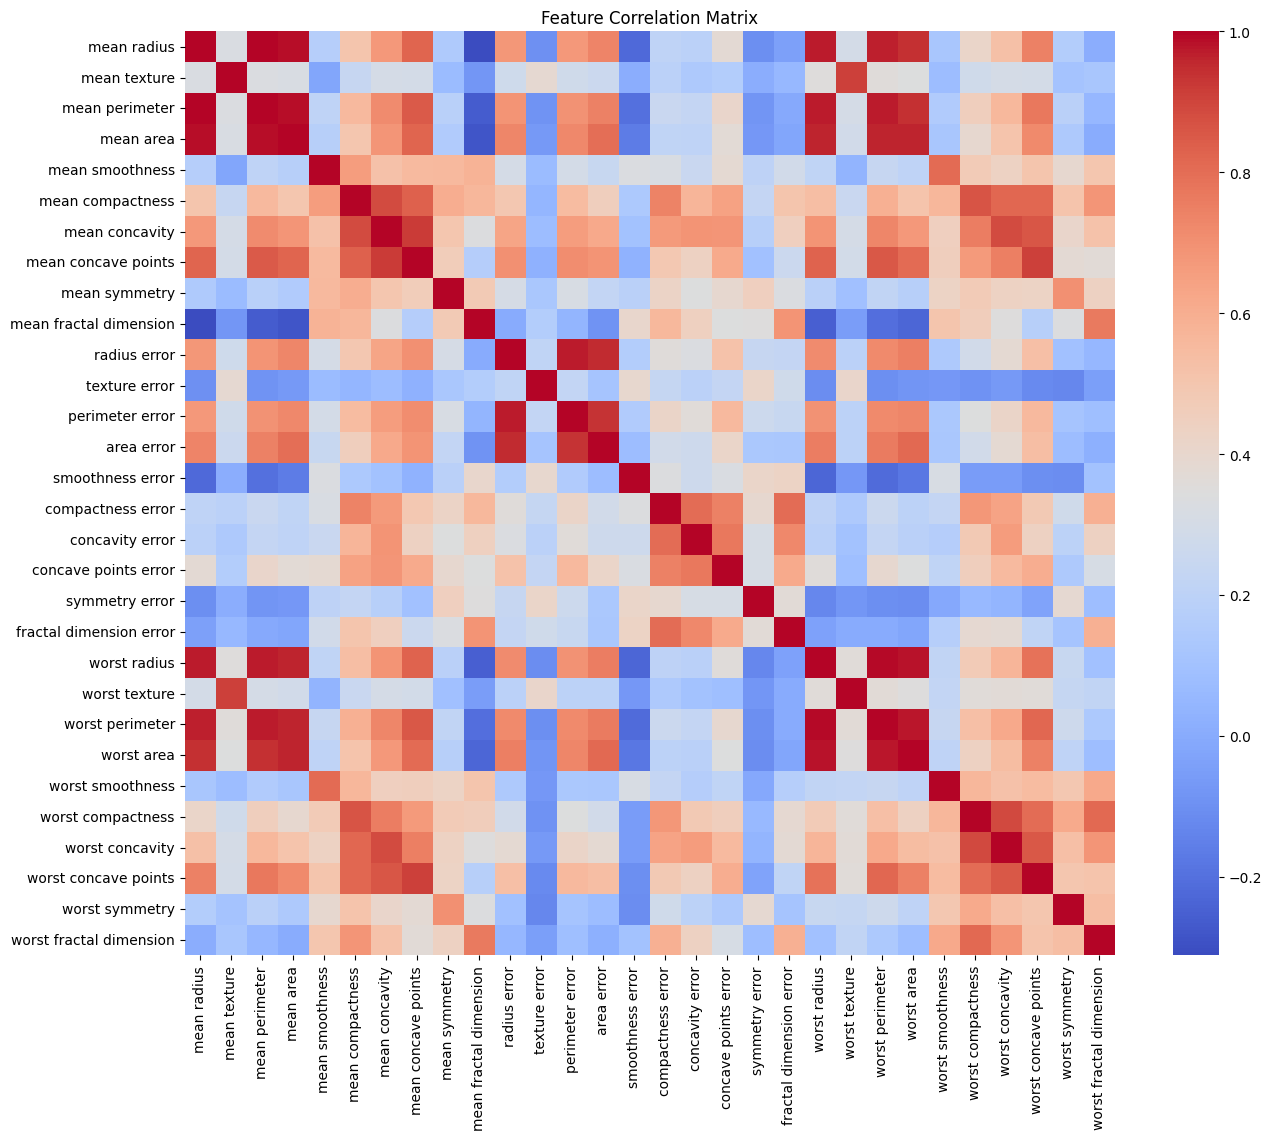

In [6]:
# Corelation Matrix

plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [7]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (455, 30)
Testing: (114, 30)


In [8]:
# Logistic Regression

lr_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),

    (
        'model',
        LogisticRegression(
            max_iter=5000
        )
    )
])

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [9]:
# SVM

svm_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),

    (
        'model',
        SVC(
            probability=True,
            kernel='rbf',
            random_state=42
        )
    )
])

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(
    X_test
)

svm_prob = svm_model.predict_proba(
    X_test
)[:,1]

In [10]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [11]:
# XGBoost

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [12]:
# Evaluate

def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    return {
        'Model': name,

        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),

        'Precision': precision_score(
            y_true,
            y_pred
        ),

        'Recall': recall_score(
            y_true,
            y_pred
        ),

        'F1 Score': f1_score(
            y_true,
            y_pred
        ),

        'ROC-AUC': roc_auc_score(
            y_true,
            y_prob
        )
    }

In [13]:
# Compare Models

results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        'SVM',
        y_test,
        svm_pred,
        svm_prob
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        'XGBoost',
        y_test,
        xgb_pred,
        xgb_prob
    )
)

results_df = pd.DataFrame(
    results
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056
3,XGBoost,0.964912,0.959459,0.986111,0.972603,0.994378


(0.0, 1.0)

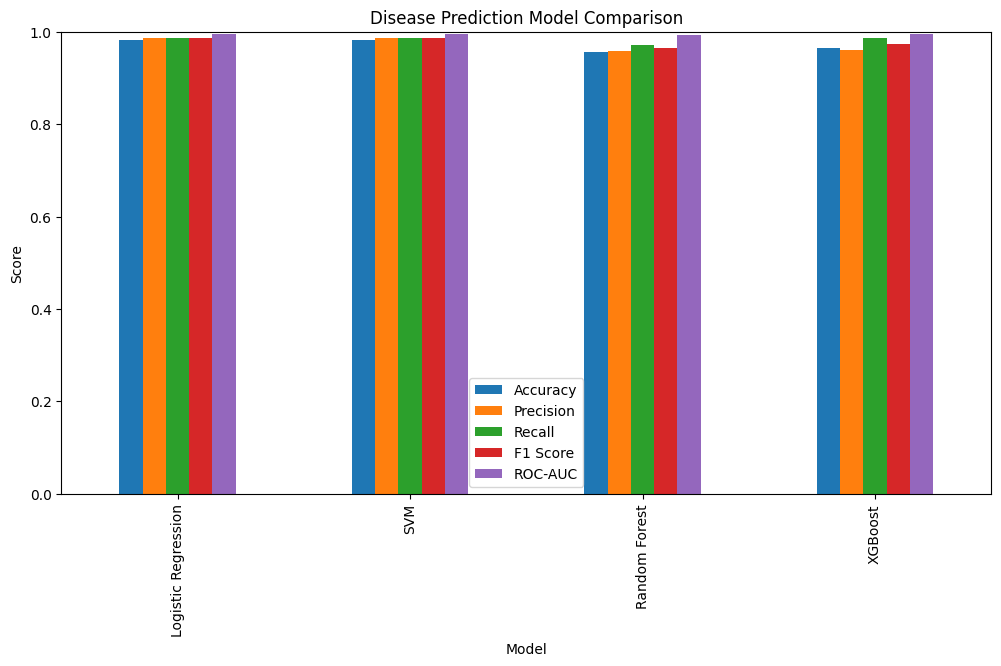

In [14]:
# Visulize Comparission

results_df.set_index(
    'Model'
).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Disease Prediction Model Comparison"
)

plt.ylabel("Score")

plt.ylim(0,1)

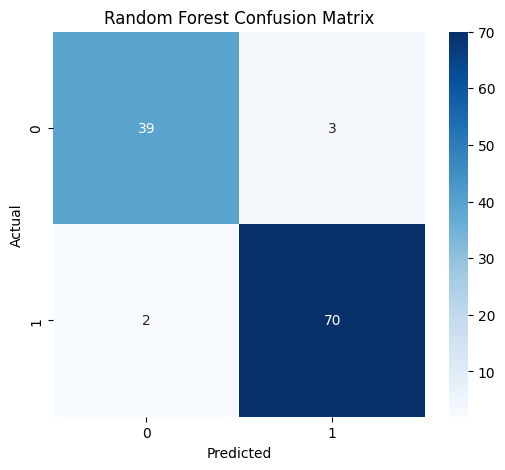

In [15]:
# Random Forest Confusion Matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
# XGBoost Classfications Reports

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



<Figure size 1000x700 with 0 Axes>

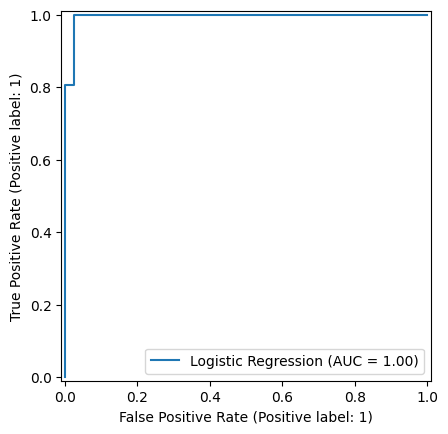

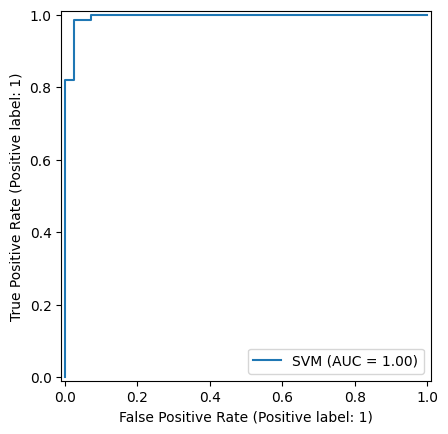

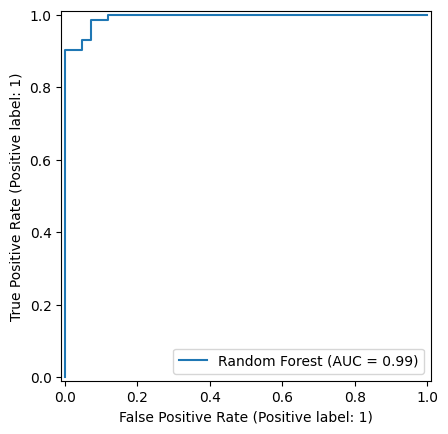

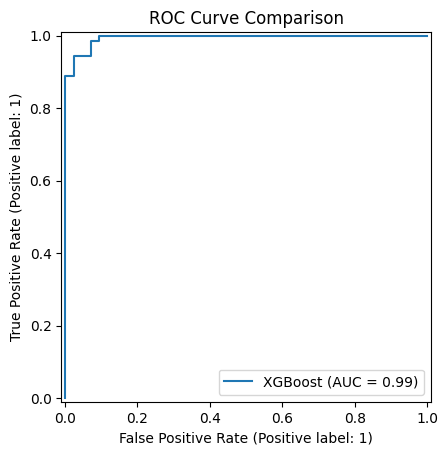

In [17]:
# ROC Curve

plt.figure(figsize=(10,7))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    svm_prob,
    name='SVM'
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name='Random Forest'
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name='XGBoost'
)

plt.title(
    "ROC Curve Comparison"
)

plt.show()

In [18]:
# Feature Imp

feature_importance = pd.DataFrame({

    'Feature':
        X.columns,

    'Importance':
        rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


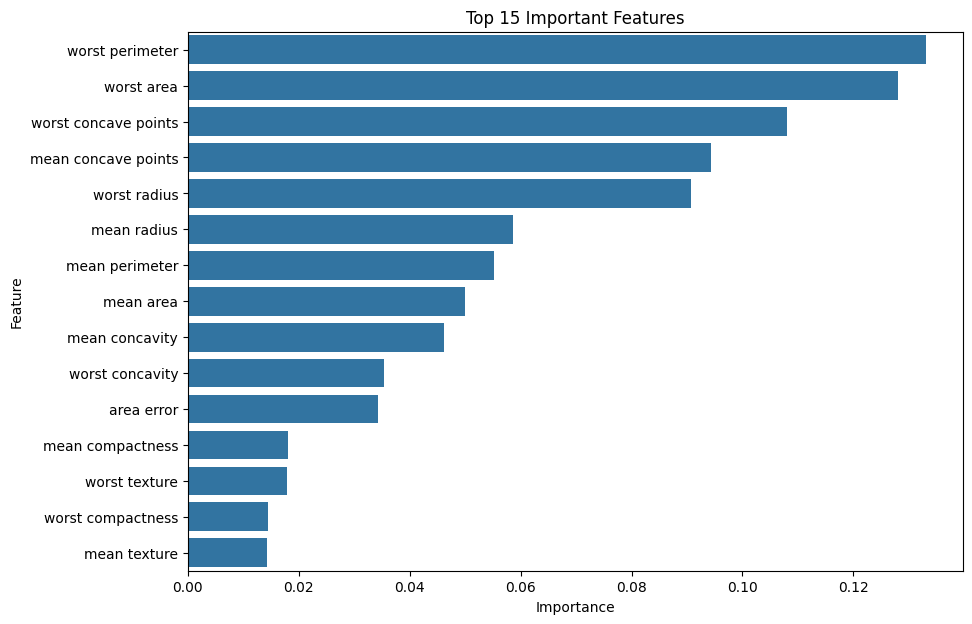

In [19]:
# Plot

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [20]:
# Save Model

best_model_name = results_df.loc[
    results_df['F1 Score'].idxmax(),
    'Model'
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Logistic Regression


In [21]:
import joblib

joblib.dump(
    xgb_model,
    "disease_prediction_model.pkl"
)

print("Model saved.")

Model saved.


In [22]:
# Use one patient/sample from the test dataset:

sample = X_test.iloc[0:1]

prediction = xgb_model.predict(
    sample
)[0]

probability = xgb_model.predict_proba(
    sample
)[0]

print(
    "Prediction:",
    data.target_names[prediction]
)

print(
    "Probability:",
    probability[prediction]
)

Prediction: malignant
Probability: 0.99865055


**Steps Performed**

**Step 1: Dataset Collection**

For this task, we developed a Disease Prediction Model using structured medical data.

The CodeAlpha task requires predicting the possibility of diseases based on patient information. The suggested medical features include:

Symptoms

Age

Blood test results

Other patient-related medical information

The suggested datasets include Heart Disease, Diabetes, and Breast Cancer datasets.

**Step 2: Data Understanding**

The medical dataset was first analyzed to understand:

Number of patients

Number of medical features

Data types

Missing values

Duplicate records

Target/disease column

Distribution of disease classes

This step helped us understand which patient information can be used to predict the disease.

**Step 3: Data Preprocessing**

The medical data was cleaned and prepared before applying machine learning.

The preprocessing included:

Handling missing values
Removing unnecessary columns
Checking duplicate records
Converting categorical data into numerical form where required
Separating input features and target variable

Preparing the dataset for machine learning

This step is important because machine-learning algorithms require properly formatted input data.

**Step 4: Feature Selection**

Important medical features were selected as input variables.

Depending on the selected dataset, these can include:

Age

Symptoms

Blood pressure

Blood test results

Cholesterol

Glucose

Other medical measurements

The model uses these features to learn patterns associated with the disease.

The basic relationship is:

Patient Medical Data
↓

Symptoms + Age + Test Results
        ↓

Machine Learning Model
        ↓

Disease Prediction

The exact features depend on the medical dataset selected.

**Step 5: Target Variable**

The disease/diagnosis column was selected as the target variable.

The model learns from previously labeled medical records.

For example:

Patient Medical Features

          ↓

     Disease Label
          ↓
      ML Training

This makes the task a classification problem.

**Step 6: Data Encoding**

If the dataset contains categorical values, they are converted into numerical values so that the machine-learning algorithm can process them.

The target disease labels can also be encoded using LabelEncoder when required.

For example:

No Disease → 0

Disease    → 1

For a multi-class disease dataset, multiple numerical classes can be created.

**Step 7: Train-Test Split**

The dataset was divided into training and testing data.

A common split is:

80% Training Data
20% Testing Data

The training data is used to learn patterns from patient records, while the testing data is used to evaluate the model on unseen records.


**Step 8: Model Building**

For this task, a classification algorithm is used to predict disease possibility.

The CodeAlpha instructions specifically suggest:

SVM

Logistic Regression

Random Forest

XGBoost

For example, if we use Random Forest, multiple decision trees are trained on the medical features and their predictions are combined to produce the final disease prediction.

**Step 9: Model Training**

The selected machine-learning model was trained using the training dataset.

The model learns relationships between medical features and disease outcomes.


The model does not simply depend on one medical feature. It learns patterns from combinations of available patient information.

**Step 10: Model Evaluation**

After training, the model was evaluated using the testing dataset.

The important evaluation metrics include:

Accuracy

Precision

Recall

F1-score

ROC-AUC where applicable

Confusion Matrix

The CodeAlpha instructions specifically mention evaluating classification models using metrics such as Precision, Recall, F1-Score, and ROC-AUC for the related classification tasks.

These metrics help us understand how effectively the model predicts disease and non-disease cases.

**Step 11: Disease Prediction**

After training and evaluation, the model can be used to predict the disease possibility for a new patient.

The complete process is:



New Patient Data
       ↓
Data Preprocessing
       ↓
Feature Selection
       ↓
Trained ML Model
       ↓
Disease Prediction
       ↓
Predicted Class

For example:

Age
Blood Pressure
Cholesterol
Other Medical Features
        ↓
 Random Forest Model
        ↓
   Prediction
        ↓
Disease / No Disease

The exact output depends on the dataset and trained model.

**Step 12: Prediction Probability**

For models that support probability prediction, we can also calculate the probability associated with each class.

For example:

No Disease → 18%
Disease     → 82%

Final Prediction → Disease

The class with the highest probability is selected as the model's prediction.

Important: This prediction is a machine-learning output and should not be treated as a medical diagnosis.

**Step 13: Complete Working of Task**

             MEDICAL DATASET
                    ↓
             Data Understanding
                    ↓
             Data Preprocessing
                    ↓
              Feature Selection
                    ↓
              Data Encoding
                    ↓
              Train/Test Split
                    ↓
             Classification Model
                    ↓
              Model Training
                    ↓
             Model Evaluation
                    ↓
       Accuracy / Precision / Recall
             F1 / ROC-AUC
                    ↓
            New Patient Data
                    ↓
             Disease Prediction
                    ↓
        Predicted Disease / Class

**Conclusion :**

We successfully developed a Disease Prediction Model from structured medical data as specified in the CodeAlpha Machine Learning task. The project started by understanding patient medical information such as symptoms, age, blood test results, and other relevant medical features. The data was then cleaned, preprocessed, and prepared for machine-learning classification.

After preprocessing, important medical features were used as input variables and the disease/diagnosis was used as the target variable. The dataset was divided into training and testing data, and a classification algorithm such as Random Forest, SVM, Logistic Regression, or XGBoost was used to learn the relationship between patient information and disease outcomes.

The trained model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC where applicable. Finally, new patient medical information was provided to the trained model, which processed the information and predicted the most likely disease class.

Overall, this task helped us understand how machine learning can be applied to structured healthcare data for disease classification and prediction. It provided practical knowledge of medical-data preprocessing, feature selection, classification algorithms, model training, performance evaluation, and prediction. The project demonstrates the potential of machine learning as a decision-support tool in healthcare, while the model's predictions should not be considered a substitute for professional medical diagnosis.